# Machine Learning Basics
## Homework 3
**Amirali Dehghani - 810102443**


### Question 8

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 443
PATH = "data/diabetes.csv"

#### Part 1: Data Preprocessing and Exploration


##### 1-1) Load dataset and separate features and labels

In [ ]:
data = pd.read_csv(PATH)
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

##### 1-2) Check for zeros in medically unrealistic columns

In [ ]:
cols_with_zero_as_missing = ["Glucose", "BloodPressure", "BMI", "SkinThickness", "Insulin"]

for col in cols_with_zero_as_missing:
    zero_count = (X[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")

Glucose: 5 zeros
BloodPressure: 35 zeros
BMI: 11 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros


##### 1-3) Replace zeros with mean of the respective columns

In [ ]:
X_clean = X.copy()
for col in cols_with_zero_as_missing:
    median_value = X_clean[col].replace(0, np.nan).median()
    X_clean[col] = X_clean[col].replace(0, median_value)
# Extra : Checking the number of zeros after fixing data
for col in cols_with_zero_as_missing:
    zero_count = (X_clean[col] == 0).sum()
    print(f"After fixing -> {col}: {zero_count} zeros")

After fixing -> Glucose: 0 zeros
After fixing -> BloodPressure: 0 zeros
After fixing -> BMI: 0 zeros
After fixing -> SkinThickness: 0 zeros
After fixing -> Insulin: 0 zeros


##### 1-4) Split the dataset into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.3, random_state=SEED, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (537, 8)
Test shape: (231, 8)


##### 1-5) Apply feature scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

#### Part 2: Linear SVM Classification

##### Before Scaling

In [ ]:
clf_linear = LinearSVC(max_iter=5000, random_state=SEED)
clf_linear.fit(X_train, y_train)

y_pred_linear = clf_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
cm_linear = confusion_matrix(y_test, y_pred_linear)

print("Linear SVM WITHOUT scaling")
print(f"Accuracy: {acc_linear:.4f}")
print("Confusion Matrix:")
print(cm_linear)

Linear SVM WITHOUT scaling
Accuracy: 0.7273
Confusion Matrix:
[[132  18]
 [ 45  36]]


##### After Scaling

In [ ]:
clf_linear_scaled = LinearSVC(max_iter=5000, random_state=SEED)
clf_linear_scaled.fit(X_train_scaled, y_train)

y_pred_linear_scaled = clf_linear_scaled.predict(X_test_scaled)

acc_linear_scaled = accuracy_score(y_test, y_pred_linear_scaled)
cm_linear_scaled = confusion_matrix(y_test, y_pred_linear_scaled)

print("Linear SVM WITH scaling")
print(f"Accuracy: {acc_linear_scaled:.4f}")
print("Confusion Matrix:")
print(cm_linear_scaled)


Linear SVM WITH scaling
Accuracy: 0.7316
Confusion Matrix:
[[132  18]
 [ 44  37]]


#### Part 3: Comparison of Diffrent Kernels

Linear Kernel
Accuracy: 0.7316
Precision: 0.6792
Recall: 0.4444
F1-score: 0.5373
Confusion Matrix:
[[133  17]
 [ 45  36]]


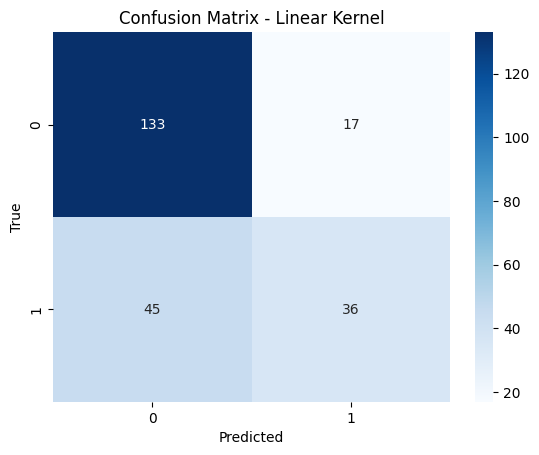

RBF Kernel
Accuracy: 0.7662
Precision: 0.7368
Recall: 0.5185
F1-score: 0.6087
Confusion Matrix:
[[135  15]
 [ 39  42]]


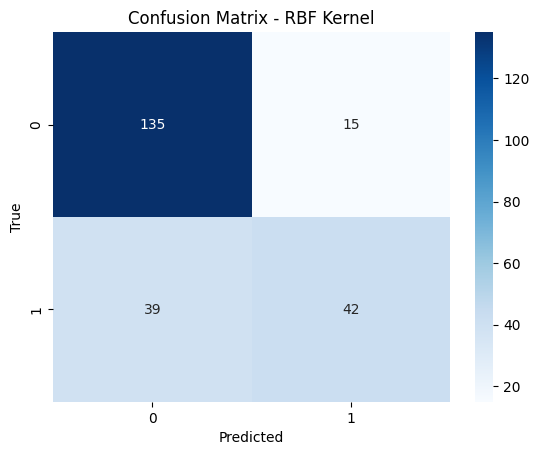

Polynomial Kernel
Accuracy: 0.7013
Precision: 0.6429
Recall: 0.3333
F1-score: 0.4390
Confusion Matrix:
[[135  15]
 [ 54  27]]


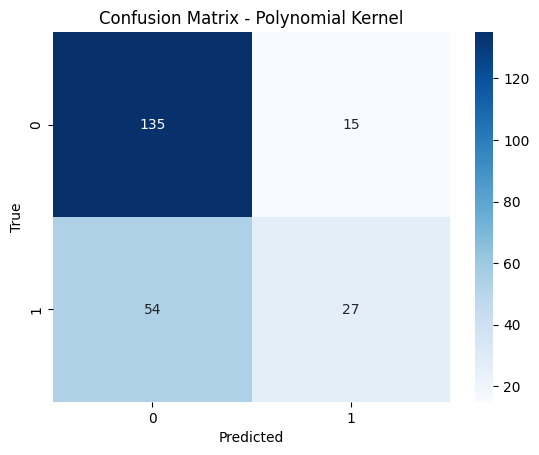


Summary Table
Linear {'accuracy': 0.7316017316017316, 'precision': 0.6792452830188679, 'recall': 0.4444444444444444, 'f1': 0.5373134328358209, 'cm': array([[133,  17],
       [ 45,  36]])}
RBF {'accuracy': 0.7662337662337663, 'precision': 0.7368421052631579, 'recall': 0.5185185185185185, 'f1': 0.6086956521739131, 'cm': array([[135,  15],
       [ 39,  42]])}
Polynomial {'accuracy': 0.7012987012987013, 'precision': 0.6428571428571429, 'recall': 0.3333333333333333, 'f1': 0.43902439024390244, 'cm': array([[135,  15],
       [ 54,  27]])}


In [ ]:
kernels = {
    "Linear": SVC(kernel='linear', random_state=SEED),
    "RBF": SVC(kernel='rbf', random_state=SEED),
    "Polynomial": SVC(kernel='poly', degree=3, random_state=SEED)
}

results = {}

for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "cm": cm
    }

    print(f"{name} Kernel")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name} Kernel")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

print("\nSummary Table")
for name, r in results.items():
    print(name, r)

#### Part 4: Hyperparameter Tuning

In [ ]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

svm_rbf = SVC(kernel="rbf", random_state=SEED)

grid = GridSearchCV(
    estimator=svm_rbf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)
acc_test_best = accuracy_score(y_test, y_pred_best)
cm_test_best = confusion_matrix(y_test, y_pred_best)

print("Test accuracy (best model):", acc_test_best)
print("Confusion Matrix (best model):")
print(cm_test_best)

Best parameters: {'C': 100, 'gamma': 0.001}
Best CV accuracy: 0.7895465559016961
Test accuracy (best model): 0.7316017316017316
Confusion Matrix (best model):
[[133  17]
 [ 45  36]]


#### Part 5: Dimensionality Reduction and Visualization

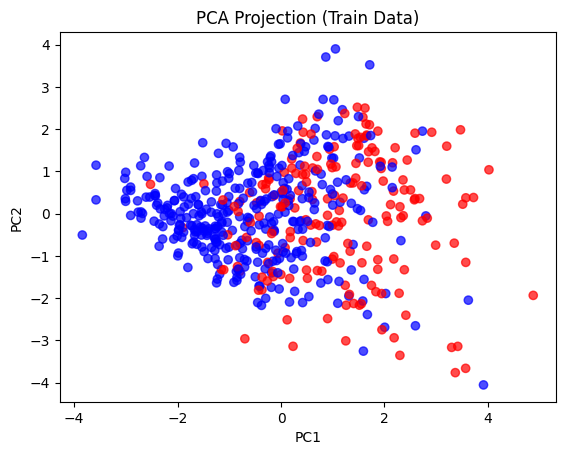

Accuracy (SVM on PCA data): 0.683982683982684


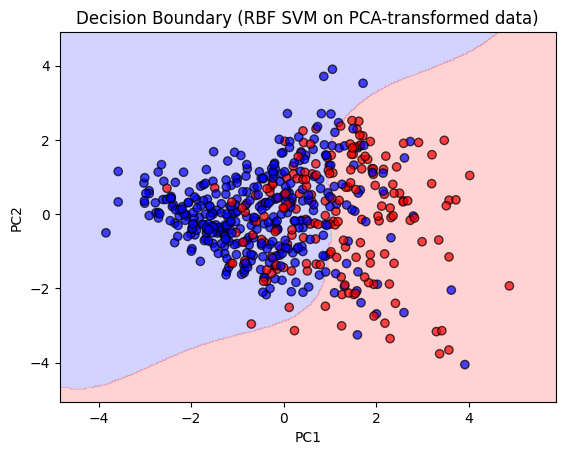

In [ ]:
pca = PCA(n_components=2, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure()
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='bwr', alpha=0.7)
plt.title("PCA Projection (Train Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

clf_pca = SVC(kernel='rbf', random_state=SEED)
clf_pca.fit(X_train_pca, y_train)

y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("Accuracy (SVM on PCA data):", acc_pca)

xx, yy = np.meshgrid(
    np.linspace(X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1, 300),
    np.linspace(X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf_pca.predict(grid).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.2)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='bwr', edgecolors='k', alpha=0.7)
plt.title("Decision Boundary (RBF SVM on PCA-transformed data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### Part 6: Class Imbalance Analysis

##### Compute number of samples in each class

In [ ]:
unique, counts = np.unique(y, return_counts=True)
class_counts = dict(zip(unique, counts))
print("Class counts (full dataset):", class_counts)

Class counts (full dataset): {np.int64(0): np.int64(500), np.int64(1): np.int64(268)}


##### SVM without class weight

In [ ]:
svm_std = SVC(kernel="rbf", random_state=SEED)
svm_std.fit(X_train_scaled, y_train)

y_pred_std = svm_std.predict(X_test_scaled)

acc_std = accuracy_score(y_test, y_pred_std)
cm_std = confusion_matrix(y_test, y_pred_std)
recall_std = recall_score(y_test, y_pred_std, pos_label=1)

print("Standard RBF SVM")
print("Accuracy:", acc_std)
print("Confusion Matrix:")
print(cm_std)
print("Recall (class 1):", recall_std)

Standard RBF SVM
Accuracy: 0.7662337662337663
Confusion Matrix:
[[135  15]
 [ 39  42]]
Recall (class 1): 0.5185185185185185


##### SVM with class weight

In [ ]:
svm_bal = SVC(kernel="rbf", class_weight="balanced", random_state=SEED)
svm_bal.fit(X_train_scaled, y_train)

y_pred_bal = svm_bal.predict(X_test_scaled)

acc_bal = accuracy_score(y_test, y_pred_bal)
cm_bal = confusion_matrix(y_test, y_pred_bal)
recall_bal = recall_score(y_test, y_pred_bal, pos_label=1)

print("RBF SVM (class_weight='balanced')")
print("Accuracy:", acc_bal)
print("Confusion Matrix:")
print(cm_bal)
print("Recall (class 1):", recall_bal)


RBF SVM (class_weight='balanced')
Accuracy: 0.7445887445887446
Confusion Matrix:
[[118  32]
 [ 27  54]]
Recall (class 1): 0.6666666666666666


### Question 9: The QP-SVM Primal Challenge: Optimizing and Visualizing the Soft-Margin Hyperplane SVM

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import cvxpy as cp
import matplotlib.pyplot as plt

PATH = "data/Social_Network_Ads.csv"
SEED = 443

#### Data Preprocessing

##### Data Loading and Label Preprocessing

In [30]:
data = pd.read_csv(PATH)

X = data[["Age", "EstimatedSalary"]].values
y_original = data["Purchased"].values

y = np.where(y_original == 1, 1, -1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels in y:", np.unique(y))
data.head()

X shape: (400, 2)
y shape: (400,)
Unique labels in y: [-1  1]


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


##### Spliting Data and Feature Scaling

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, shuffle=True
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)


(280, 2) (120, 2)


#### QP Formulation and Solution

In [32]:
C = 1.0

n_features = X_train_scaled.shape[1]
n_samples = X_train_scaled.shape[0]

w = cp.Variable(n_features)
b = cp.Variable()
xi = cp.Variable(n_samples, nonneg=True)

constraints = [
    cp.multiply(y_train, X_train_scaled @ w + b) >= 1 - xi
]

objective = cp.Minimize(0.5 * cp.sum_squares(w) + C * cp.sum(xi))

problem = cp.Problem(objective, constraints)
problem.solve()

w_opt = w.value
b_opt = b.value

print("Status:", problem.status)
print("w*:", w_opt)
print("b*:", b_opt)


Status: optimal
w*: [1.55264218 0.92965445]
b*: -0.7343137254901964


#### Model Evaluation:

In [33]:
y_scores = X_test_scaled @ w_opt + b_opt
y_pred = np.sign(y_scores)

accuracy = np.mean(y_pred == y_test)

print("Test accuracy (QP-SVM):", accuracy)

Test accuracy (QP-SVM): 0.875


#### Visualizing the Decision Boundary

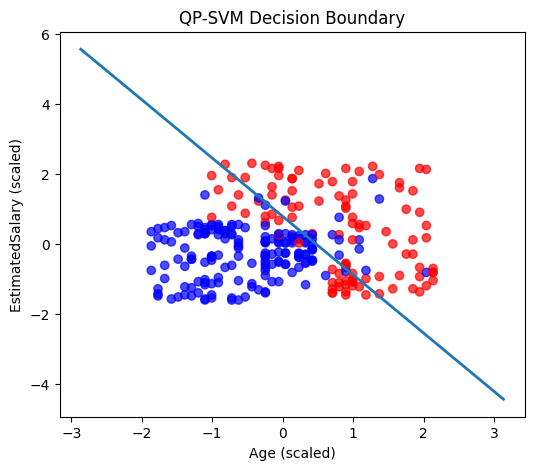

In [34]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    cmap="bwr",
    alpha=0.7
)

x1_vals = np.linspace(
    X_train_scaled[:, 0].min() - 1,
    X_train_scaled[:, 0].max() + 1,
    200
)
x2_vals = -(w_opt[0] * x1_vals + b_opt) / w_opt[1]

plt.plot(x1_vals, x2_vals, linewidth=2)

plt.xlabel("Age (scaled)")
plt.ylabel("EstimatedSalary (scaled)")
plt.title("QP-SVM Decision Boundary")
plt.show()


### Question 10: Decision Tree Classifier 

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from copy import deepcopy

PATH = "data/jeeves_tennis.csv"
SEED = 443

#### Data Loading & Pre-processing

##### Load Jeeves Tennis Dataset

In [12]:
df = pd.read_csv("data/jeeves_tennis.csv")
print(df.head())
print(df.columns)

   Day_ID   Outlook  Temperature Humidity    Wind PlayTennis
0       1      Rain         19.2     High  Strong         No
1       2      Rain         17.4      Low    Weak        Yes
2       3     Sunny         29.9   Normal  Strong        Yes
3       4  Overcast         23.2   Normal    Weak        Yes
4       5     Sunny         29.3     High    Weak         No
Index(['Day_ID', 'Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis'], dtype='object')


##### Entropy and Information Gain Functions

In [13]:
def calculate_entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs))

def calculate_information_gain(data, feature, target):
    total_entropy = calculate_entropy(data[target].values)
    values, counts = np.unique(data[feature], return_counts=True)
    weighted_entropy = 0.0
    n = len(data)
    for v, c in zip(values, counts):
        subset_labels = data[data[feature] == v][target].values
        weighted_entropy += (c / n) * calculate_entropy(subset_labels)
    return total_entropy - weighted_entropy

root_entropy = calculate_entropy(df["PlayTennis"].values)
ig_day_id = calculate_information_gain(df, "Day_ID", "PlayTennis")

print("Root entropy H(PlayTennis):", root_entropy)
print("Information Gain for Day_ID:", ig_day_id)

Root entropy H(PlayTennis): 0.9814538950336537
Information Gain for Day_ID: 0.9814538950336537


##### Dropping Irrelevant Columns ("Day_ID" Column)

In [14]:
df = df.drop(columns=["Day_ID"])
print(df.head())

    Outlook  Temperature Humidity    Wind PlayTennis
0      Rain         19.2     High  Strong         No
1      Rain         17.4      Low    Weak        Yes
2     Sunny         29.9   Normal  Strong        Yes
3  Overcast         23.2   Normal    Weak        Yes
4     Sunny         29.3     High    Weak         No


##### Compute Information Gain for Discrete Attributes

In [15]:
ig_outlook = calculate_information_gain(df, "Outlook", "PlayTennis")
ig_humidity = calculate_information_gain(df, "Humidity", "PlayTennis")
ig_wind = calculate_information_gain(df, "Wind", "PlayTennis")

print("IG(Outlook):", ig_outlook)
print("IG(Humidity):", ig_humidity)
print("IG(Wind):", ig_wind)


IG(Outlook): 0.34307121026106036
IG(Humidity): 0.05389337220677792
IG(Wind): 0.03822828269585188


#### Handling Continuous Features

In [16]:
def find_best_split(data, attribute, target):
    df_sorted = data.sort_values(attribute).reset_index(drop=True)
    x_vals = df_sorted[attribute].values
    y_vals = df_sorted[target].values

    candidate_thresholds = []
    for i in range(len(x_vals) - 1):
        if y_vals[i] != y_vals[i + 1]:
            t = (x_vals[i] + x_vals[i + 1]) / 2.0
            candidate_thresholds.append(t)

    best_gain = -np.inf
    best_t = None
    n = len(df_sorted)
    parent_entropy = calculate_entropy(y_vals)

    for t in candidate_thresholds:
        left_labels = df_sorted[df_sorted[attribute] <= t][target].values
        right_labels = df_sorted[df_sorted[attribute] > t][target].values

        left_entropy = calculate_entropy(left_labels)
        right_entropy = calculate_entropy(right_labels)

        weighted_entropy = (len(left_labels) / n) * left_entropy + \
                           (len(right_labels) / n) * right_entropy

        gain = parent_entropy - weighted_entropy

        if gain > best_gain:
            best_gain = gain
            best_t = t

    return best_t, best_gain

best_t, best_gain = find_best_split(df, "Temperature", "PlayTennis")
print("Best threshold for Temperature:", best_t)
print("Information Gain at this threshold:", best_gain)


Best threshold for Temperature: 30.05
Information Gain at this threshold: 0.02392309702606632


#### Recursive Tree Construction

In [17]:
class DecisionTreeID3:
    def __init__(self, min_samples_split=1, max_depth=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.tree_ = None

    def fit(self, data, target):
        features = [col for col in data.columns if col != target]
        self.tree_ = self._build_tree(data, features, target, depth=0)

    def _build_tree(self, data, features, target, depth):
        labels = data[target].values
        if len(np.unique(labels)) == 1:
            return {"is_leaf": True, "prediction": labels[0]}

        if len(features) == 0:
            values, counts = np.unique(labels, return_counts=True)
            majority_label = values[np.argmax(counts)]
            return {"is_leaf": True, "prediction": majority_label}

        if self.max_depth is not None and depth >= self.max_depth:
            values, counts = np.unique(labels, return_counts=True)
            majority_label = values[np.argmax(counts)]
            return {"is_leaf": True, "prediction": majority_label}

        if len(data) < self.min_samples_split:
            values, counts = np.unique(labels, return_counts=True)
            majority_label = values[np.argmax(counts)]
            return {"is_leaf": True, "prediction": majority_label}

        best_feature = None
        best_threshold = None
        best_gain = -np.inf

        for feature in features:
            if feature == "Temperature":
                t, gain = find_best_split(data, feature, target)
                if t is None:
                    continue
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = t
            else:
                gain = calculate_information_gain(data, feature, target)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = None

        if best_feature is None:
            values, counts = np.unique(labels, return_counts=True)
            majority_label = values[np.argmax(counts)]
            return {"is_leaf": True, "prediction": majority_label}

        node = {
            "is_leaf": False,
            "feature": best_feature,
            "threshold": best_threshold,
            "children": {}
        }

        if best_threshold is not None:
            left_data = data[data[best_feature] <= best_threshold]
            right_data = data[data[best_feature] > best_threshold]

            if len(left_data) == 0 or len(right_data) == 0:
                values, counts = np.unique(labels, return_counts=True)
                majority_label = values[np.argmax(counts)]
                return {"is_leaf": True, "prediction": majority_label}

            node["children"]["<="] = self._build_tree(
                left_data, features, target, depth + 1
            )
            node["children"][">"] = self._build_tree(
                right_data, features, target, depth + 1
            )
        else:
            remaining_features = [f for f in features if f != best_feature]
            for v in np.unique(data[best_feature]):
                subset = data[data[best_feature] == v]
                if len(subset) == 0:
                    values, counts = np.unique(labels, return_counts=True)
                    majority_label = values[np.argmax(counts)]
                    node["children"][v] = {"is_leaf": True, "prediction": majority_label}
                else:
                    node["children"][v] = self._build_tree(
                        subset, remaining_features, target, depth + 1
                    )

        return node

    def _predict_one(self, x):
        node = self.tree_
        while not node["is_leaf"]:
            feature = node["feature"]
            threshold = node["threshold"]
            if threshold is not None:
                if x[feature] <= threshold:
                    node = node["children"]["<="]
                else:
                    node = node["children"][">"]
            else:
                value = x[feature]
                if value in node["children"]:
                    node = node["children"][value]
                else:
                    values = []
                    leaves = []

                    def collect_leaves(n):
                        if n["is_leaf"]:
                            leaves.append(n["prediction"])
                        else:
                            for ch in n["children"].values():
                                collect_leaves(ch)

                    collect_leaves(node)
                    values_arr, counts = np.unique(leaves, return_counts=True)
                    majority_label = values_arr[np.argmax(counts)]
                    return majority_label
        return node["prediction"]

    def predict(self, data):
        preds = []
        for _, row in data.iterrows():
            preds.append(self._predict_one(row))
        return np.array(preds)


##### Evaluation

In [18]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, shuffle=True
)

tree = DecisionTreeID3()
tree.fit(train_df, "PlayTennis")

y_test_true = test_df["PlayTennis"].values
y_test_pred = tree.predict(test_df)

acc = accuracy_score(y_test_true, y_test_pred)
prec = precision_score(y_test_true, y_test_pred, pos_label="Yes")
rec = recall_score(y_test_true, y_test_pred, pos_label="Yes")

print("Test accuracy:", acc)
print("Test precision (Yes):", prec)
print("Test recall (Yes):", rec)

Test accuracy: 0.93
Test precision (Yes): 0.9032258064516129
Test recall (Yes): 0.9824561403508771


#### Overfitting & Pruning Analysis

##### Compute Tree Depth and Number of Leaf Nodes

In [19]:
def tree_depth(node):
    if node["is_leaf"]:
        return 1
    return 1 + max(tree_depth(child) for child in node["children"].values())

def count_leaves(node):
    if node["is_leaf"]:
        return 1
    return sum(count_leaves(child) for child in node["children"].values())

depth_clean = tree_depth(tree.tree_)
leaves_clean = count_leaves(tree.tree_)

print("Tree depth (clean):", depth_clean)
print("Leaf count (clean):", leaves_clean)


Tree depth (clean): 12
Leaf count (clean): 37


##### Noise Simulation

In [20]:
train_noisy = train_df.copy()

n_train = len(train_noisy)
n_flip = int(0.1 * n_train)

rng = np.random.default_rng(SEED)
flip_indices = rng.choice(train_noisy.index, size=n_flip, replace=False)

for idx in flip_indices:
    current_label = train_noisy.at[idx, "PlayTennis"]
    train_noisy.at[idx, "PlayTennis"] = "No" if current_label == "Yes" else "Yes"

noisy_tree = DecisionTreeID3()
noisy_tree.fit(train_noisy, "PlayTennis")

depth_noisy = tree_depth(noisy_tree.tree_)
leaves_noisy = count_leaves(noisy_tree.tree_)

print("Tree depth (noisy):", depth_noisy)
print("Leaf count (noisy):", leaves_noisy)


Tree depth (noisy): 13
Leaf count (noisy): 100


##### Post-Pruning Experiment

tolerance | tree_size | test_accuracy
0.0 13 0.91
0.005 13 0.91
0.01 13 0.91
0.02 13 0.91
0.05 13 0.91


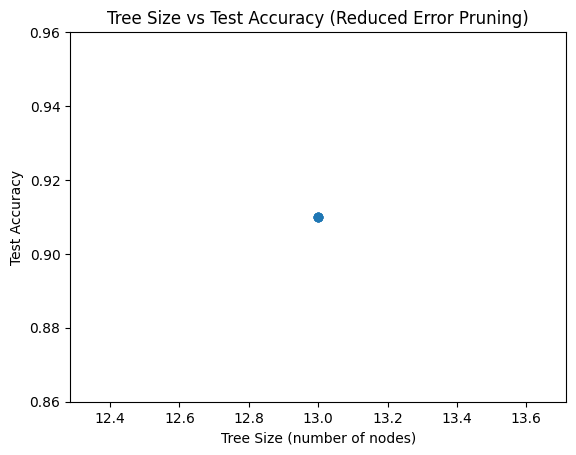

In [21]:
train_sub, val_df = train_test_split(
    train_df, test_size=0.3, random_state=SEED, shuffle=True
)

base_tree = DecisionTreeID3()
base_tree.fit(train_sub, "PlayTennis")

def evaluate_tree_accuracy(tree_obj, data, target):
    y_true = data[target].values
    y_pred = tree_obj.predict(data)
    return accuracy_score(y_true, y_pred)

def count_nodes(node):
    if node["is_leaf"]:
        return 1
    return 1 + sum(count_nodes(ch) for ch in node["children"].values())

def prune_node(node, data, target, tolerance):
    if node["is_leaf"]:
        return node, data

    feature = node["feature"]
    threshold = node["threshold"]

    splits = {}

    if threshold is not None:
        left_mask = data[feature] <= threshold
        right_mask = data[feature] > threshold
        splits["<="] = data[left_mask]
        splits[">"] = data[right_mask]
    else:
        for v in node["children"].keys():
            splits[v] = data[data[feature] == v]

    for key, child in node["children"].items():
        child_data = splits.get(key, data.iloc[0:0])
        pruned_child, _ = prune_node(child, child_data, target, tolerance)
        node["children"][key] = pruned_child

    if len(data) == 0:
        return node, data

    temp_tree = DecisionTreeID3()
    temp_tree.tree_ = node
    acc_full = evaluate_tree_accuracy(temp_tree, data, target)

    labels = data[target].values
    values, counts = np.unique(labels, return_counts=True)
    majority_label = values[np.argmax(counts)]

    leaf_node = {"is_leaf": True, "prediction": majority_label}

    temp_leaf_tree = DecisionTreeID3()
    temp_leaf_tree.tree_ = leaf_node
    acc_leaf = evaluate_tree_accuracy(temp_leaf_tree, data, target)

    if acc_leaf >= acc_full - tolerance:
        return leaf_node, data
    else:
        return node, data

def prune_tree(tree_obj, val_data, target, tolerance):
    new_tree = deepcopy(tree_obj)
    pruned_root, _ = prune_node(new_tree.tree_, val_data, target, tolerance)
    new_tree.tree_ = pruned_root
    return new_tree

tolerances = [0.0, 0.005, 0.01, 0.02, 0.05]

sizes = []
test_accs = []

print("tolerance | tree_size | test_accuracy")
for tol in tolerances:
    pruned = prune_tree(base_tree, val_df, "PlayTennis", tol)
    size = count_nodes(pruned.tree_)
    acc_test = accuracy_score(y_test_true, pruned.predict(test_df))

    sizes.append(size)
    test_accs.append(acc_test)

    print(tol, size, acc_test)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(sizes, test_accs, marker="o")
plt.xlabel("Tree Size (number of nodes)")
plt.ylabel("Test Accuracy")
plt.title("Tree Size vs Test Accuracy (Reduced Error Pruning)")
plt.show()
